# Data exploration — MVTec AD

Before running any method, we look at the data and make sure our design choices for the feature extractor are grounded. This notebook covers:

1. What MVTec AD looks like: categories, splits, defect types.
2. Sample images per defect type for the `pill` and `grid` categories.
3. Why `layer3` of ResNet-18: feature-map spatial resolution vs semantic content across layers.

Reference: Bergmann et al., *MVTec AD — A Comprehensive Real-World Dataset for Unsupervised Anomaly Detection*, CVPR 2019.

In [1]:
import sys
sys.path.append("..")

from pathlib import Path
from collections import Counter

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models

from src.dataset import MVTecDataset, IMAGENET_MEAN, IMAGENET_STD

DATA_ROOT = Path("../data/mvtec")
IMAGE_SIZE = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("categories available:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))

device: cuda
categories available: ['grid', 'pill']


## MVTec structure

Each category has the same folder layout:
```
<category>/
train/good/.png              (normal training images)
test/good/.png               (normal test images)
test/<defect_type>/.png      (defective test images per type)
ground_truth/<defect_type>/.png   (pixel-level anomaly masks)
```

The training set has only `good` images. This is the "unsupervised" part: at fit time the model never sees a defect. It builds a model of normality and flags deviations at test time.

In [2]:
for category in ["pill", "grid"]:
    cat_dir = DATA_ROOT / category
    train_ds = MVTecDataset(DATA_ROOT, category, is_train=True)
    test_ds  = MVTecDataset(DATA_ROOT, category, is_train=False)

    defect_counts = Counter(
        Path(p).parent.name for p in test_ds.image_paths
    )

    print(f"\n[{category}]")
    print(f"  train (good only): {len(train_ds)}")
    print(f"  test total       : {len(test_ds)}")
    print(f"  test breakdown   :")
    for defect, n in sorted(defect_counts.items()):
        marker = "normal" if defect == "good" else "anomaly"
        print(f"    {defect:20s} {n:3d}   ({marker})")


[pill]
  train (good only): 267
  test total       : 167
  test breakdown   :
    color                 25   (anomaly)
    combined              17   (anomaly)
    contamination         21   (anomaly)
    crack                 26   (anomaly)
    faulty_imprint        19   (anomaly)
    good                  26   (normal)
    pill_type              9   (anomaly)
    scratch               24   (anomaly)

[grid]
  train (good only): 264
  test total       : 78
  test breakdown   :
    bent                  12   (anomaly)
    broken                12   (anomaly)
    glue                  11   (anomaly)
    good                  21   (normal)
    metal_contamination   11   (anomaly)
    thread                11   (anomaly)


## Sample images per defect type

One image per defect type for each of our two categories. This is what the models will actually see. Look at the pills: many "defects" are subtle — a few pixels of unexpected color, a small dent, a thin crack. That is why anomaly detection is hard and worth the modelling effort.

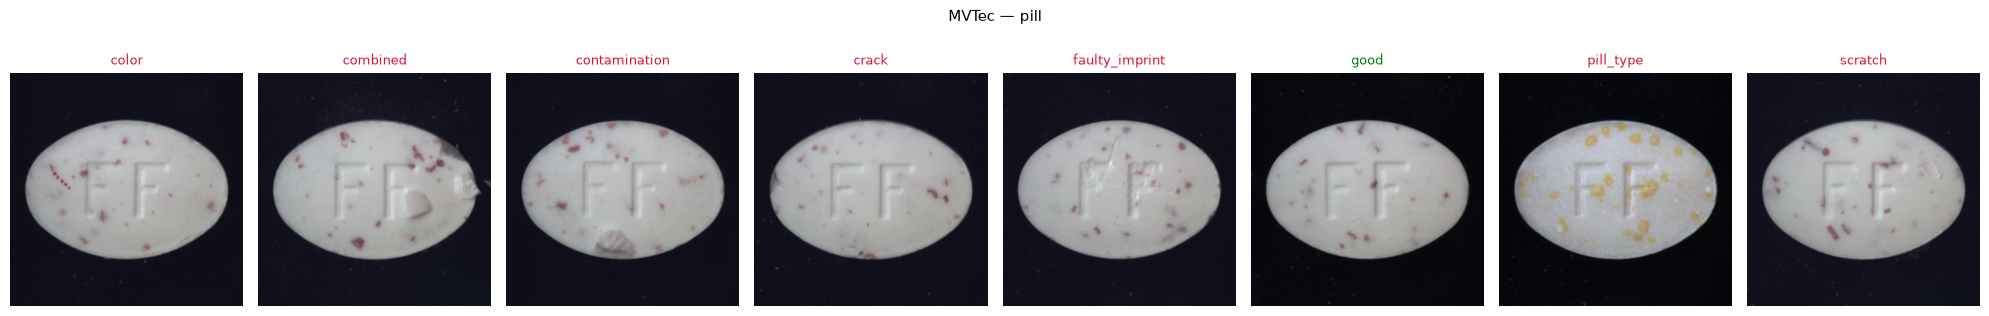

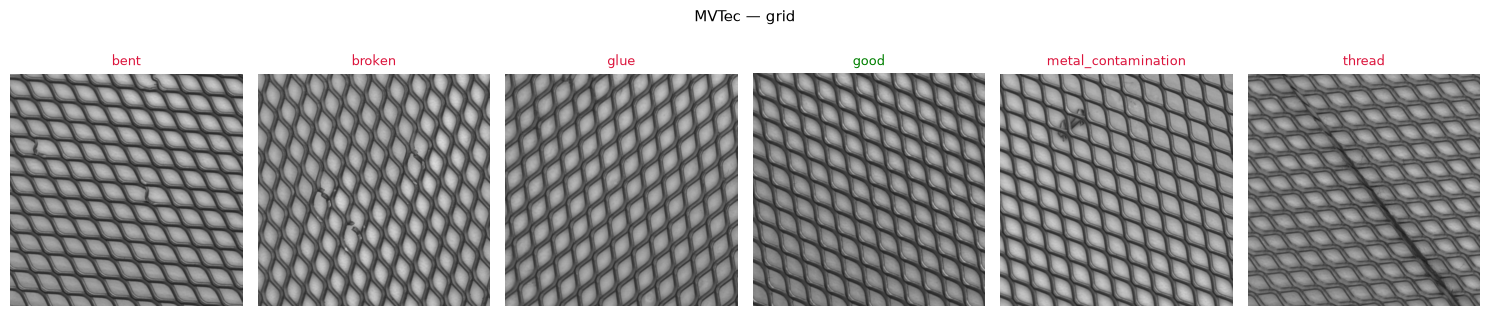

In [3]:
def show_defect_gallery(category, ncols=None):
    """Grid of sample images: one per defect type."""
    cat_dir = DATA_ROOT / category / "test"
    defect_types = sorted(d.name for d in cat_dir.iterdir() if d.is_dir())
    ncols = ncols or len(defect_types)

    fig, axes = plt.subplots(1, len(defect_types), figsize=(2.5 * len(defect_types), 3))
    if len(defect_types) == 1:
        axes = [axes]

    for ax, defect in zip(axes, defect_types):
        img_path = next((cat_dir / defect).glob("*.png"))
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        color = "green" if defect == "good" else "crimson"
        ax.set_title(defect, color=color, fontsize=9)
        ax.axis("off")

    fig.suptitle(f"MVTec — {category}", fontsize=11, y=1.05)
    fig.tight_layout()
    return fig

_ = show_defect_gallery("pill")
_ = show_defect_gallery("grid")
plt.show()

## Feature-map resolution across ResNet layers

The core design choice for feature-space anomaly detection is *which layer to tap*. Deeper layers give more semantic features but coarser spatial resolution; shallower layers preserve spatial detail but the features are more generic (mostly edges and textures).

We measure output shape at each ResNet-18 layer for a 224x224 input to make the trade-off concrete.

In [4]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).eval()
x = torch.randn(1, 3, 224, 224)

layers = {
    "conv1 -> maxpool": torch.nn.Sequential(
        resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool),
    "layer1": torch.nn.Sequential(
        resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool, resnet.layer1),
    "layer2": torch.nn.Sequential(
        resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool, resnet.layer1, resnet.layer2),
    "layer3": torch.nn.Sequential(
        resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool, resnet.layer1, resnet.layer2, resnet.layer3),
    "layer4": torch.nn.Sequential(
        resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool, resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4),
}

print(f"input                : {tuple(x.shape)}")
print(f"{'layer':22s} {'output shape':22s} {'receptive field (px)':22s} {'features per img':15s}")
print("-" * 82)
with torch.no_grad():
    for name, block in layers.items():
        y = block(x)
        C, H, W = y.shape[1:]
        rf_ratio = IMAGE_SIZE / H
        print(f"{name:22s} {str(tuple(y.shape)):22s} ~{rf_ratio:5.1f} px / feature       {C*H*W:>10d}")

input                : (1, 3, 224, 224)
layer                  output shape           receptive field (px)   features per img
----------------------------------------------------------------------------------
conv1 -> maxpool       (1, 64, 56, 56)        ~  4.0 px / feature           200704
layer1                 (1, 64, 56, 56)        ~  4.0 px / feature           200704
layer2                 (1, 128, 28, 28)       ~  8.0 px / feature           100352
layer3                 (1, 256, 14, 14)       ~ 16.0 px / feature            50176
layer4                 (1, 512, 7, 7)         ~ 32.0 px / feature            25088


## Reading the table

- **layer1** (56x56, 64 channels) preserves fine spatial detail but the features are low-level (edges, colors, small textures). Not semantic enough for feature-space anomaly detection to work well.
- **layer2** (28x28, 128 channels) starts to be semantic but per-pixel Gaussians would need ~800 covariance parameters per location. Reasonable, but redundant.
- **layer3** (14x14, 256 channels) is the sweet spot for MVTec-scale defects. Each feature cell covers about a 16x16 pixel region in the original image, small enough to localize color specks and broken wires, large enough to carry semantic content.
- **layer4** (7x7, 512 channels) is very semantic but only 49 spatial cells. Fine for image-level classification, too coarse for the small defects in MVTec.

The methods in this repo use **layer3**. Multi-scale approaches (concatenating layer2 + layer3, as PatchCore does) can help, and are on the roadmap.

## Feature map visualization

To build intuition, we visualize the first 8 channels of the `layer3` feature map for a normal and a defective pill. Different channels encode different aspects of texture and shape. The differences between "normal" and "defect" activations are what the anomaly detectors will pick up.

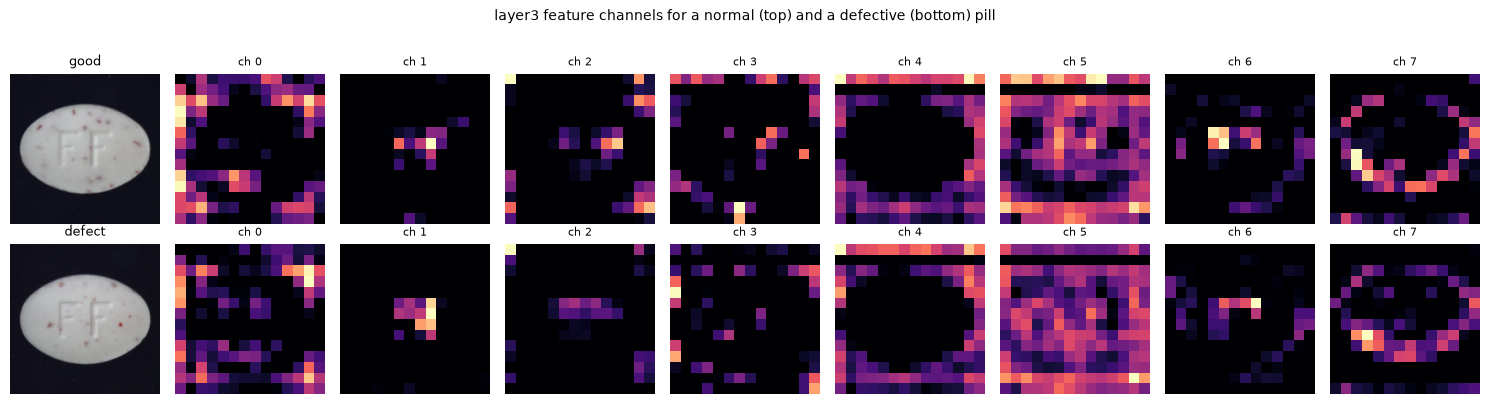

In [5]:
from src.features import FeatureExtractor

tfm = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
extractor = FeatureExtractor(stop_layer="layer3").to(device)

test_ds = MVTecDataset(DATA_ROOT, "pill", is_train=False, transform=tfm)
normal_idx  = next(i for i in range(len(test_ds)) if test_ds.labels[i] == 0)
defect_idx  = next(i for i in range(len(test_ds)) if test_ds.labels[i] == 1)

def features_of(idx):
    img, lbl = test_ds[idx]
    with torch.no_grad():
        f = extractor(img.unsqueeze(0).to(device)).squeeze(0).cpu()
    return img, f, lbl

img_n, fmap_n, _ = features_of(normal_idx)
img_d, fmap_d, _ = features_of(defect_idx)

fig, axes = plt.subplots(2, 9, figsize=(15, 4))
for row, (img, fmap, tag) in enumerate([(img_n, fmap_n, "good"),
                                        (img_d, fmap_d, "defect")]):
    img_np = img.cpu().numpy().transpose(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN
    axes[row, 0].imshow(np.clip(img_np, 0, 1))
    axes[row, 0].set_title(tag, fontsize=9)
    axes[row, 0].axis("off")
    for c in range(8):
        axes[row, c + 1].imshow(fmap[c].numpy(), cmap="magma")
        axes[row, c + 1].set_title(f"ch {c}", fontsize=8)
        axes[row, c + 1].axis("off")

fig.suptitle("layer3 feature channels for a normal (top) and a defective (bottom) pill",
             fontsize=10, y=1.02)
fig.tight_layout()
plt.show()

## Takeaway for the methods

- Training a per-pixel Gaussian on the layer3 feature map (`GaussianAD`) means fitting `N(mu, Sigma)` at each of the 14x14 = 196 spatial positions, with `mu` and `Sigma` living in 256 dimensions. Diagonal covariance keeps this to ~50k parameters per category.
- A memory bank over the same feature map (`NearestNeighborAD`) has a natural size of `N x 14 x 14` vectors per category. For pill's 267 training images that is ~52k vectors of 256 dims, ~54 MB uncompressed. We cap at 20k to keep scoring fast.

See `02_padim_baseline.ipynb` and `03_knn_method.ipynb` for the two methods in action.